In [83]:
import numpy as np
import torch
import torchvision
from torch.utils.data import dataloader
import torchvision.transforms.functional as TF

from tqdm import tqdm
import mlflow
import os
import matplotlib.pyplot as plt

In [84]:
import cv2
from dataset import mask_to_centers, DOTA_MEAN, DOTA_STD
from inference import draw_centers, load_checkpoint, predict_sliding_window, find_peaks, compute_metrics_at_threshold, match_centers, get_gaussian_weight_map
from loss import CenterLoss

In [25]:
RANDOM_STATE = 1619
TILE_SIZE = 512
STRIDE = 384
THRESHOLD = 0.3
MATCH_RADIUS = 20.0

In [18]:
device ="mps" if torch.backends.mps.is_available() else  "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
## mlflow set-up
experiment_name = "co-patch-attack-trial1"
mlflow.set_experiment(experiment_name)

In [66]:
# Init the attack
img_path = "segdata/DOTA/DOTA_PLANES_TILED/train/image/P0023_obj_27.png"
mask_path = "segdata/DOTA/DOTA_PLANES_TILED/train/mask/P0023_obj_27.png"
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
gt_centers = mask_to_centers(gt_mask * 255)

base_features = torch.load("segdata/DOTA/DOTA_PLANES_TILED_CACHED_FEATURES/base/train/P0022_obj_6.pt")

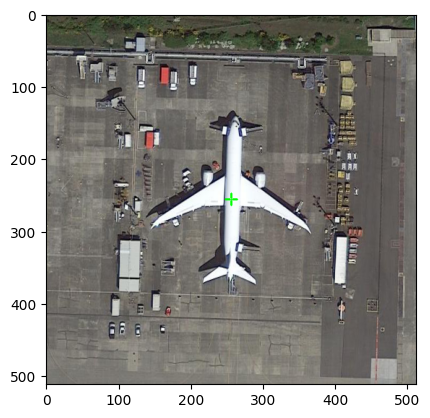

In [67]:
thickness = max(2, int(max(img.shape[:2]) / 500))
radius = max(8, int(max(img.shape[:2]) / 200))
vis_gt = draw_centers(img, gt_centers, (0, 255, 0), radius=radius, thickness=thickness)
plt.imshow(vis_gt)

In [68]:
# load the model
ckpt_path = "runs/16_02-21_05_12_BASE_animal-variation.pth"
model = load_checkpoint(ckpt_path, device)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

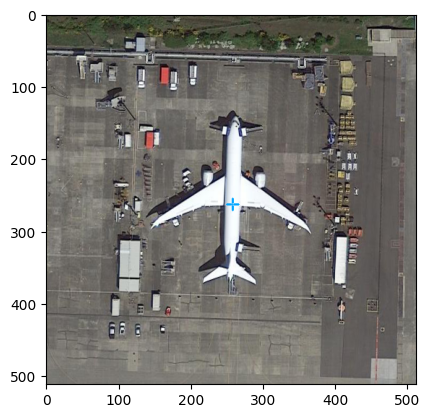

In [107]:
# Predict:
prob_map = predict_sliding_window(model, img, device=device)
pred_centers = find_peaks(prob_map, threshold=THRESHOLD)
heatmap = prob_map
vis_pred = draw_centers(img, pred_centers, (0, 165, 255), radius=radius, thickness=thickness)
plt.imshow(vis_pred)

In [108]:
tp, fp, fn = match_centers(gt_centers, pred_centers)
print("TP = ", tp, "| FP = ", fp, "| FN = ", fn)

TP =  1 | FP =  0 | FN =  0


In [109]:
type(img)

numpy.ndarray

In [110]:
# Add Patch on the top corner
PATCH_SIZE = 36
patch = np.zeros_like(img)
patch[0:PATCH_SIZE, 0:PATCH_SIZE] = 1
weight_map = get_gaussian_weight_map(TILE_SIZE, device)


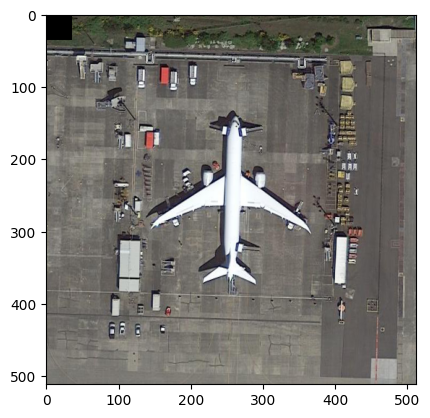

In [133]:
model.eval();
x = img*(1-patch)
x_t = torch.from_numpy(x).permute(2, 0, 1).float() / 255.0
x_t = TF.normalize(x_t, DOTA_MEAN, DOTA_STD)
x_t = x_t.unsqueeze(0).to(device)
print(x_t.shape)

with torch.no_grad():
    logits = model(x_t)
    prob = torch.sigmoid(logits).squeeze()
    print("Prob = ", prob)
    
prob_map = (prob * weight_map).cpu().numpy()
pred_centers = find_peaks(prob_map, threshold=THRESHOLD)
vis_pred = draw_centers(img, pred_centers, (0, 165, 255), radius=radius, thickness=thickness);


torch.Size([1, 3, 512, 512])
Prob =  tensor([[0.0155, 0.0144, 0.0152,  ..., 0.0433, 0.0405, 0.0422],
        [0.0077, 0.0049, 0.0052,  ..., 0.0259, 0.0250, 0.0386],
        [0.0090, 0.0054, 0.0057,  ..., 0.0302, 0.0289, 0.0428],
        ...,
        [0.0319, 0.0216, 0.0221,  ..., 0.0181, 0.0159, 0.0204],
        [0.0326, 0.0215, 0.0215,  ..., 0.0203, 0.0181, 0.0187],
        [0.0214, 0.0200, 0.0207,  ..., 0.0187, 0.0156, 0.0128]],
       device='mps:0')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


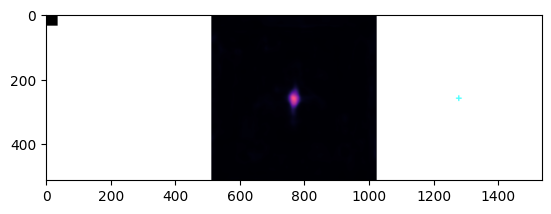

In [147]:
prob_color = plt.get_cmap("magma")(prob_map)[..., :3]  # HxW x3, drop alpha
prob_color = prob_color / prob_color.max()

comparison = np.concatenate([x, prob_color, vis_pred], axis=1)
plt.imshow(comparison)
plt.show()

In [149]:
x

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 21,  29,  40],
        [ 50,  59,  68],
        [178, 186, 188]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 20,  28,  39],
        [ 52,  60,  70],
        [176, 185, 186]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 13,  21,  32],
        [ 51,  60,  69],
        [174, 183, 184]],

       ...,

       [[124, 123, 118],
        [121, 120, 115],
        [120, 119, 114],
        ...,
        [131, 130, 125],
        [128, 127, 123],
        [129, 128, 124]],

       [[122, 121, 116],
        [121, 120, 115],
        [120, 119, 114],
        ...,
        [129, 128, 123],
        [125, 124, 120],
        [128, 127, 123]],

       [[121, 120, 115],
        [121, 120, 115],
        [120, 119, 114],
        ...,
        [129, 128, 123],
        [126, 125, 121],
        [128, 127, 123]]

In [150]:
prob_color

array([[[0.00274387, 0.00157365, 0.02227539],
        [0.00274387, 0.00157365, 0.02227539],
        [0.00274387, 0.00157365, 0.02227539],
        ...,
        [0.0072303 , 0.0058851 , 0.04511949],
        [0.00548287, 0.00424096, 0.03641275],
        [0.00548287, 0.00424096, 0.03641275]],

       [[0.00177659, 0.00056627, 0.01684963],
        [0.00177659, 0.00056627, 0.01684963],
        [0.00177659, 0.00056627, 0.01684963],
        ...,
        [0.00398456, 0.00280098, 0.02880939],
        [0.00398456, 0.00280098, 0.02880939],
        [0.00548287, 0.00424096, 0.03641275]],

       [[0.00177659, 0.00056627, 0.01684963],
        [0.00177659, 0.00056627, 0.01684963],
        [0.00177659, 0.00056627, 0.01684963],
        ...,
        [0.00398456, 0.00280098, 0.02880939],
        [0.00398456, 0.00280098, 0.02880939],
        [0.0072303 , 0.0058851 , 0.04511949]],

       ...,

       [[0.00548287, 0.00424096, 0.03641275],
        [0.00398456, 0.00280098, 0.02880939],
        [0.00398456, 0

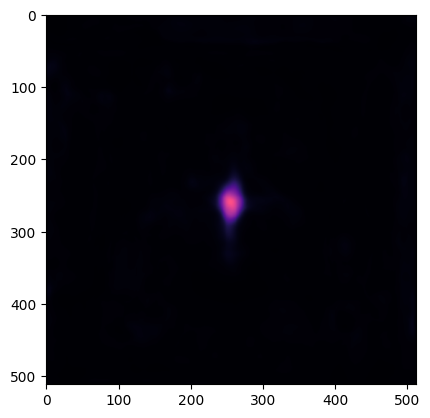

In [138]:
plt.imshow(prob_color)
plt.show()

In [56]:
with mlflow.start_run(run_name="baseline_logreg") as run:
    with torch.no_grad():
        marker = 

SyntaxError: invalid syntax (198416357.py, line 3)